# ❤️ CardioPredict AI — Entraînement du Modèle
Adaptation de `train_model.py` en notebook pour visualiser l'entraînement.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle
import os

## 2. Chargement du Dataset
Dataset Heart Disease UCI (Cleveland) — 303 patients, 13 features, cible binaire.  
Si `heart.csv` est présent localement, on l'utilise. Sinon on tente le téléchargement, puis on génère des données réalistes en fallback.

In [2]:
FEATURES = ["age","sex","cp","trestbps","chol","fbs","restecg",
            "thalach","exang","oldpeak","slope","ca","thal"]

def generate_realistic_dataset(n=303, seed=42):
    """Génère un dataset synthétique avec les mêmes distributions que UCI Cleveland."""
    np.random.seed(seed)
    n0, n1 = 165, 138  # sains vs malades

    def gen(n, sick):
        return {
            "age":      np.random.normal(52 if not sick else 56, 9, n).clip(29,77).astype(int),
            "sex":      np.random.choice([0,1], n, p=[0.32,0.68] if not sick else [0.25,0.75]),
            "cp":       np.random.choice([0,1,2,3], n, p=[0.47,0.17,0.28,0.08] if not sick else [0.79,0.07,0.07,0.07]),
            "trestbps": np.random.normal(129 if not sick else 134, 17, n).clip(94,200).astype(int),
            "chol":     np.random.normal(242 if not sick else 251, 53, n).clip(126,564).astype(int),
            "fbs":      np.random.choice([0,1], n, p=[0.85,0.15]),
            "restecg":  np.random.choice([0,1,2], n, p=[0.50,0.48,0.02] if not sick else [0.62,0.35,0.03]),
            "thalach":  np.random.normal(158 if not sick else 139, 21, n).clip(71,202).astype(int),
            "exang":    np.random.choice([0,1], n, p=[0.86,0.14] if not sick else [0.41,0.59]),
            "oldpeak":  np.abs(np.random.normal(0.6 if not sick else 1.6, 0.9, n)).clip(0,6.2).round(1),
            "slope":    np.random.choice([0,1,2], n, p=[0.02,0.38,0.60] if not sick else [0.06,0.58,0.36]),
            "ca":       np.random.choice([0,1,2,3], n, p=[0.75,0.14,0.07,0.04] if not sick else [0.42,0.26,0.19,0.13]),
            "thal":     np.random.choice([1,2,3], n, p=[0.06,0.74,0.20] if not sick else [0.04,0.40,0.56]),
            "target":   np.zeros(n, dtype=int) if not sick else np.ones(n, dtype=int),
        }

    healthy = pd.DataFrame(gen(n0, False))
    sick    = pd.DataFrame(gen(n1, True))
    df = pd.concat([healthy, sick]).sample(frac=1, random_state=seed).reset_index(drop=True)
    return df

if os.path.exists("heart.csv"):
    df = pd.read_csv("heart.csv")
    df.columns = [c.strip().lower() for c in df.columns]
    if "condition" in df.columns:
        df.rename(columns={"condition": "target"}, inplace=True)
    df["target"] = (df["target"] > 0).astype(int)
    df.dropna(inplace=True)
    print(f"✅ Dataset chargé depuis heart.csv ({len(df)} lignes)")
else:
    try:
        url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/heartdisease.csv"
        df = pd.read_csv(url)
        df.columns = [c.strip().lower() for c in df.columns]
        df["target"] = (df["target"] > 0).astype(int)
        df.dropna(inplace=True)
        df.to_csv("heart.csv", index=False)
        print(f"✅ Dataset téléchargé ({len(df)} lignes)")
    except Exception:
        df = generate_realistic_dataset()
        df.to_csv("heart.csv", index=False)
        print(f"✅ Dataset synthétique généré ({len(df)} lignes)")

print(f"   Distribution cible : {df['target'].value_counts().to_dict()}")
df.head()

✅ Dataset chargé depuis heart.csv (303 lignes)
   Distribution cible : {0: 165, 1: 138}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,40,1,0,132,264,1,0,157,0,0.6,2,3,1,1
1,61,0,0,103,339,0,0,138,1,0.4,1,0,3,1
2,51,1,1,133,274,0,1,170,0,0.0,2,1,2,0
3,44,1,0,126,238,0,0,128,0,0.6,1,1,2,1
4,47,1,3,134,228,1,0,143,0,0.6,2,0,2,0


## 3. Préparation des Données

In [3]:
X = df[FEATURES]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train : {X_train.shape[0]} échantillons | Test : {X_test.shape[0]} échantillons")

Train : 242 échantillons | Test : 61 échantillons


## 4. Entraînement — Random Forest

In [4]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    class_weight="balanced"
)
model.fit(X_train_s, y_train)
print("✅ Modèle entraîné")

✅ Modèle entraîné


### Visualisation — Erreur OOB selon le nombre d'arbres

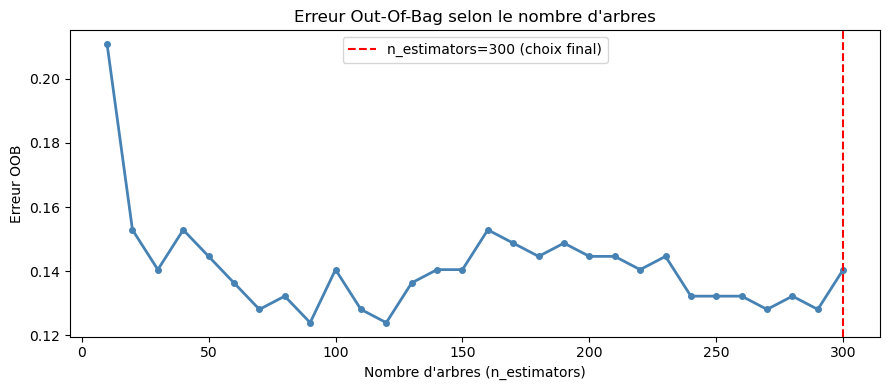

In [5]:
import matplotlib.pyplot as plt

oob_errors = []
n_range = range(10, 310, 10)

for n in n_range:
    rf = RandomForestClassifier(
        n_estimators=n, oob_score=True,
        random_state=42, class_weight="balanced"
    )
    rf.fit(X_train_s, y_train)
    oob_errors.append(1 - rf.oob_score_)

plt.figure(figsize=(9, 4))
plt.plot(list(n_range), oob_errors, marker='o', markersize=4, linewidth=2, color='steelblue')
plt.axvline(x=300, color='red', linestyle='--', label='n_estimators=300 (choix final)')
plt.xlabel("Nombre d'arbres (n_estimators)")
plt.ylabel("Erreur OOB")
plt.title("Erreur Out-Of-Bag selon le nombre d'arbres")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Évaluation

In [6]:
y_pred = model.predict(X_test_s)
acc = accuracy_score(y_test, y_pred)

print(f"\n📊 Accuracy sur le jeu de test : {acc * 100:.2f}%")
print("\n📋 Rapport de classification :")
print(classification_report(y_test, y_pred, target_names=["Sain", "Malade"]))
print("🔢 Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))


📊 Accuracy sur le jeu de test : 80.33%

📋 Rapport de classification :
              precision    recall  f1-score   support

        Sain       0.77      0.91      0.83        33
      Malade       0.86      0.68      0.76        28

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61

🔢 Matrice de confusion :
[[30  3]
 [ 9 19]]


### Visualisation — Matrice de confusion

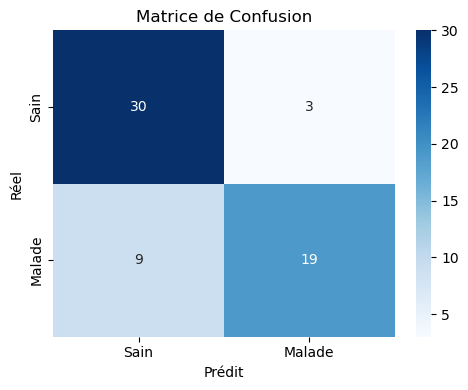

In [7]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Sain", "Malade"],
            yticklabels=["Sain", "Malade"])
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de Confusion")
plt.tight_layout()
plt.show()

### Visualisation — Importance des features

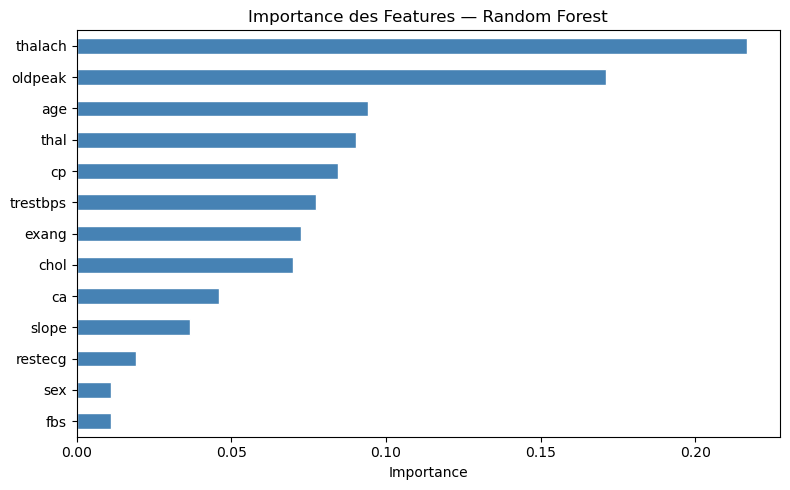

In [8]:
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.xlabel("Importance")
plt.title("Importance des Features — Random Forest")
plt.tight_layout()
plt.show()

## 6. Sauvegarde

In [9]:
with open("model.pkl", "wb") as f:
    pickle.dump({"model": model, "scaler": scaler, "features": FEATURES}, f)

print("\n✅ Modèle sauvegardé dans model.pkl")


✅ Modèle sauvegardé dans model.pkl
